# PrÃƒÂ¡ctica: RegresiÃƒÂ³n Lineal con una Variable

## Ã°Å¸Å½Â¯ Objetivos del laboratorio

En este notebook implementarÃƒÂ¡s **regresiÃƒÂ³n lineal univariable desde cero**. Al finalizar serÃƒÂ¡s capaz de:

- Implementar la funciÃƒÂ³n del modelo lineal $f_{w,b}(x) = wx + b$
- Calcular la funciÃƒÂ³n de costo $J(w,b)$
- Calcular el gradiente $\frac{\partial J}{\partial w}$ y $\frac{\partial J}{\partial b}$
- Implementar el algoritmo de descenso de gradiente
- Visualizar el proceso de entrenamiento y hacer predicciones

## Ã°Å¸â€œÅ’ Indicaciones importantes

- En cada celda con `### TU CÃƒâ€œDIGO AQUÃƒÂ ###` debes completar la implementaciÃƒÂ³n.
- **No uses operaciones vectorizadas** (operaciones de NumPy sobre arreglos completos). Usa **ciclos `for` explÃƒÂ­citos**.
- Lee con cuidado las pistas y los comentarios antes de implementar.
- DespuÃƒÂ©s de cada implementaciÃƒÂ³n hay una celda de prueba que valida tu cÃƒÂ³digo.
- Si una celda falla, revisa tu cÃƒÂ³digo antes de continuar (las funciones siguientes dependen de las anteriores).

## 1. ConfiguraciÃƒÂ³n inicial

Empezamos importando las librerÃƒÂ­as necesarias. Solo usaremos NumPy para almacenar los datos y para hacer las grÃƒÂ¡ficas (no para vectorizar operaciones).

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import math

# ConfiguraciÃƒÂ³n estÃƒÂ©tica para las grÃƒÂ¡ficas
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

## 2. Planteamiento del problema

Trabajaremos con un conjunto de datos sobre **aÃƒÂ±os de experiencia laboral** y **salario mensual** (en miles de quetzales) de profesionales en tecnologÃƒÂ­a.

Nuestro objetivo es ajustar un modelo de regresiÃƒÂ³n lineal que nos permita **predecir el salario esperado** dado los aÃƒÂ±os de experiencia de un profesional.

### NotaciÃƒÂ³n que usaremos

| SÃƒÂ­mbolo | DescripciÃƒÂ³n |
|---------|-------------|
| $x^{(i)}$ | AÃƒÂ±os de experiencia del ejemplo $i$ |
| $y^{(i)}$ | Salario (en miles de Q) del ejemplo $i$ |
| $m$ | Cantidad total de ejemplos |
| $w$ | Pendiente del modelo (parÃƒÂ¡metro) |
| $b$ | Intercepto del modelo (parÃƒÂ¡metro) |

In [56]:
# Datos de entrenamiento
# x_train: aÃƒÂ±os de experiencia
# y_train: salario en miles de quetzales

x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y_train = np.array([3.5, 4.2, 5.0, 5.8, 6.5, 7.1, 7.9, 8.6, 9.3, 10.1])

m = len(x_train)
print(f'Cantidad de ejemplos de entrenamiento: m = {m}')
print('\nDatos:')
for i in range(m):
    print(f'  x^({i}) = {x_train[i]:5.1f} aÃƒÂ±os   Ã¢â€ â€™   y^({i}) = {y_train[i]:5.2f} miles de Q')

Cantidad de ejemplos de entrenamiento: m = 10

Datos:
  x^(0) =   1.0 aÃƒÂ±os   Ã¢â€ â€™   y^(0) =  3.50 miles de Q
  x^(1) =   2.0 aÃƒÂ±os   Ã¢â€ â€™   y^(1) =  4.20 miles de Q
  x^(2) =   3.0 aÃƒÂ±os   Ã¢â€ â€™   y^(2) =  5.00 miles de Q
  x^(3) =   4.0 aÃƒÂ±os   Ã¢â€ â€™   y^(3) =  5.80 miles de Q
  x^(4) =   5.0 aÃƒÂ±os   Ã¢â€ â€™   y^(4) =  6.50 miles de Q
  x^(5) =   6.0 aÃƒÂ±os   Ã¢â€ â€™   y^(5) =  7.10 miles de Q
  x^(6) =   7.0 aÃƒÂ±os   Ã¢â€ â€™   y^(6) =  7.90 miles de Q
  x^(7) =   8.0 aÃƒÂ±os   Ã¢â€ â€™   y^(7) =  8.60 miles de Q
  x^(8) =   9.0 aÃƒÂ±os   Ã¢â€ â€™   y^(8) =  9.30 miles de Q
  x^(9) =  10.0 aÃƒÂ±os   Ã¢â€ â€™   y^(9) = 10.10 miles de Q


### VisualizaciÃƒÂ³n inicial de los datos

Antes de modelar cualquier cosa, **siempre conviene mirar los datos**.

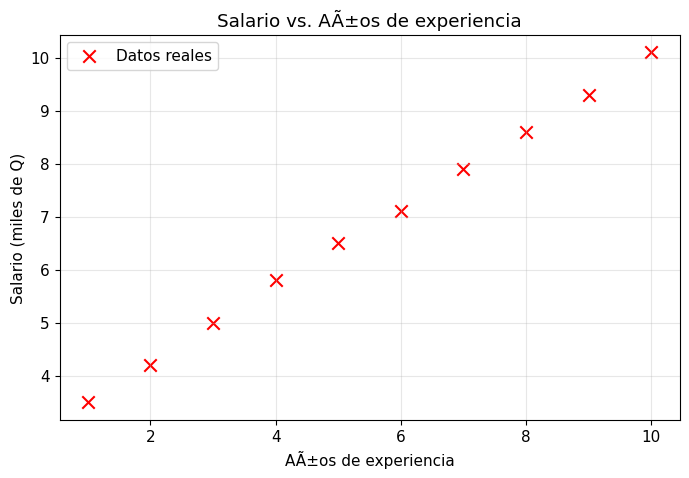

Ã°Å¸â€™Â­ Ã‚Â¿Se ve una relaciÃƒÂ³n lineal? Ã‚Â¿Tiene sentido modelar esto con una recta?


In [57]:
plt.scatter(x_train, y_train, marker='x', c='red', s=80, label='Datos reales')
plt.title('Salario vs. AÃƒÂ±os de experiencia')
plt.xlabel('AÃƒÂ±os de experiencia')
plt.ylabel('Salario (miles de Q)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Ã°Å¸â€™Â­ Ã‚Â¿Se ve una relaciÃƒÂ³n lineal? Ã‚Â¿Tiene sentido modelar esto con una recta?')

## 3. FunciÃƒÂ³n del modelo

El modelo de regresiÃƒÂ³n lineal univariable se define como:

$$f_{w,b}(x) = wx + b$$

Donde:
- $w$ es la **pendiente** (cuÃƒÂ¡nto aumenta $y$ por cada unidad de $x$).
- $b$ es el **intercepto** (valor de $y$ cuando $x = 0$).

### Ã¢Å“ÂÃ¯Â¸Â Ejercicio 1: Implementa `compute_model_output`

Implementa la funciÃƒÂ³n que calcula las predicciones del modelo para **todos** los ejemplos de $x$.

Para cada ejemplo $i$ debes calcular:

$$f_{w,b}(x^{(i)}) = w \cdot x^{(i)} + b$$

Ã°Å¸â€Â **Recordatorio:** usa un ciclo `for`, no operaciones vectorizadas.

In [58]:
def compute_model_output(x, w, b):
    """
    Calcula la predicciÃƒÂ³n del modelo lineal para cada ejemplo.

    Args:
        x (ndarray): Arreglo con m ejemplos de entrada
        w (float):   ParÃƒÂ¡metro del modelo (pendiente)
        b (float):   ParÃƒÂ¡metro del modelo (intercepto)

    Returns:
        f_wb (ndarray): Predicciones del modelo para cada x[i]
    """
    m = len(x)
    f_wb = np.zeros(m)

    ### TU CÃƒâ€œDIGO AQUÃƒÂ ### (Ã¢â€°Ë† 2 lÃƒÂ­neas)
    # Pista 1: itera sobre los m ejemplos con un ciclo for
    # Pista 2: para cada i, calcula f_wb[i] = w * x[i] + b

    for i in range(m):
        f_wb[i] = w * x[i] + b 


    ### FIN DEL CÃƒâ€œDIGO ###

    return f_wb

In [59]:
# Ã°Å¸Â§Âª Probemos tu implementaciÃƒÂ³n con valores conocidos
w_prueba = 0.7
b_prueba = 3.0

predicciones = compute_model_output(x_train, w_prueba, b_prueba)

print('Predicciones obtenidas:')
for i in range(m):
    print(f'  f_wb({x_train[i]:.1f}) = {predicciones[i]:.2f}')

# ValidaciÃƒÂ³n automÃƒÂ¡tica
esperado = np.array([3.7, 4.4, 5.1, 5.8, 6.5, 7.2, 7.9, 8.6, 9.3, 10.0])
if np.allclose(predicciones, esperado):
    print('\nÃ¢Å“â€¦ Ã‚Â¡Correcto! Tu funciÃƒÂ³n trabaja como se esperaba.')
else:
    print('\nÃ¢ÂÅ’ Las predicciones no coinciden con lo esperado. Revisa tu implementaciÃƒÂ³n.')

Predicciones obtenidas:
  f_wb(1.0) = 3.70
  f_wb(2.0) = 4.40
  f_wb(3.0) = 5.10
  f_wb(4.0) = 5.80
  f_wb(5.0) = 6.50
  f_wb(6.0) = 7.20
  f_wb(7.0) = 7.90
  f_wb(8.0) = 8.60
  f_wb(9.0) = 9.30
  f_wb(10.0) = 10.00

Ã¢Å“â€¦ Ã‚Â¡Correcto! Tu funciÃƒÂ³n trabaja como se esperaba.


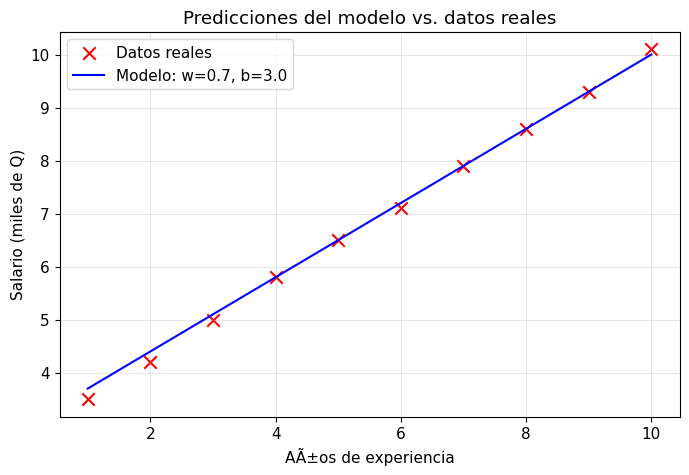

Ã°Å¸Â¤â€ Ã‚Â¿Crees que estos valores de w y b son los ÃƒÂ³ptimos?
Necesitamos una forma de medir quÃƒÂ© tan bueno es el modelo: la funciÃƒÂ³n de costo.


In [60]:
# Visualicemos las predicciones junto con los datos reales
plt.scatter(x_train, y_train, marker='x', c='red', s=80, label='Datos reales')
plt.plot(x_train, predicciones, c='blue', label=f'Modelo: w={w_prueba}, b={b_prueba}')
plt.title('Predicciones del modelo vs. datos reales')
plt.xlabel('AÃƒÂ±os de experiencia')
plt.ylabel('Salario (miles de Q)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Ã°Å¸Â¤â€ Ã‚Â¿Crees que estos valores de w y b son los ÃƒÂ³ptimos?')
print('Necesitamos una forma de medir quÃƒÂ© tan bueno es el modelo: la funciÃƒÂ³n de costo.')

## 4. FunciÃƒÂ³n de costo

La **funciÃƒÂ³n de costo** mide quÃƒÂ© tan lejos estÃƒÂ¡n las predicciones del modelo de los valores reales. Para regresiÃƒÂ³n lineal usamos el **error cuadrÃƒÂ¡tico medio**:

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

Donde:
- $f_{w,b}(x^{(i)}) - y^{(i)}$ es el **error** del ejemplo $i$.
- Elevamos al cuadrado para que los errores positivos y negativos no se cancelen.
- Dividimos entre $2m$ (el 2 es por conveniencia matemÃƒÂ¡tica, simplifica las derivadas).

### Ã¢Å“ÂÃ¯Â¸Â Ejercicio 2: Implementa `compute_cost`

Sigue estos pasos:
1. Inicializa `cost_sum = 0`
2. Para cada ejemplo $i$:
   - Calcula la predicciÃƒÂ³n: `f_wb_i = w * x[i] + b`
   - Calcula el error al cuadrado: `(f_wb_i - y[i]) ** 2`
   - Acumula ese valor en `cost_sum`
3. Al salir del ciclo, divide `cost_sum` entre $2m$

In [61]:
def compute_cost(x, y, w, b):
    """
    Calcula el costo (error cuadrÃƒÂ¡tico medio dividido entre 2)
    para los parÃƒÂ¡metros w y b dados.

    Args:
        x (ndarray): Arreglo con m ejemplos de entrada
        y (ndarray): Arreglo con m valores objetivo
        w (float):   ParÃƒÂ¡metro del modelo (pendiente)
        b (float):   ParÃƒÂ¡metro del modelo (intercepto)

    Returns:
        total_cost (float): El valor del costo J(w,b)
    """
    m = len(x)
    cost_sum = 0

    ### TU CÃƒâ€œDIGO AQUÃƒÂ ### (Ã¢â€°Ë† 4 lÃƒÂ­neas)
    # Pista 1: itera sobre los m ejemplos con un ciclo for
    # Pista 2: en cada iteraciÃƒÂ³n:
    #   - calcula la predicciÃƒÂ³n: f_wb_i = w * x[i] + b
    #   - calcula el error al cuadrado: (f_wb_i - y[i]) ** 2
    #   - sÃƒÂºmalo a cost_sum

    for i in range(m):
        f_wb_i = w * x[i] + b
        error = (f_wb_i - y[i]) ** 2
        cost_sum += error

    

    ### FIN DEL CÃƒâ€œDIGO ###

    total_cost = cost_sum / (2 * m)
    return total_cost

In [62]:
# Ã°Å¸Â§Âª Probemos tu funciÃƒÂ³n de costo con varios valores de w y b
costo_1 = compute_cost(x_train, y_train, 0.7, 3.0)
print(f'Costo con w=0.7, b=3.0: {costo_1:.4f}')

costo_2 = compute_cost(x_train, y_train, 0.0, 0.0)
print(f'Costo con w=0.0, b=0.0: {costo_2:.4f}')

costo_3 = compute_cost(x_train, y_train, 1.0, 5.0)
print(f'Costo con w=1.0, b=5.0: {costo_3:.4f}')

# ValidaciÃƒÂ³n automÃƒÂ¡tica
if math.isclose(costo_1, 0.0055, abs_tol=1e-3) and math.isclose(costo_2, 25.303, abs_tol=1e-2):
    print('\nÃ¢Å“â€¦ Ã‚Â¡Tu funciÃƒÂ³n de costo trabaja correctamente!')
    print('Ã°Å¸â€™Â¡ Observa cÃƒÂ³mo el costo es muy bajo cuando w y b estÃƒÂ¡n cerca del ÃƒÂ³ptimo,')
    print('   y muy alto cuando estÃƒÂ¡n lejos (como con w=0, b=0).')
else:
    print('\nÃ¢ÂÅ’ Los valores no coinciden con los esperados. Revisa tu implementaciÃƒÂ³n.')

Costo con w=0.7, b=3.0: 0.0055
Costo con w=0.0, b=0.0: 25.3030
Costo con w=1.0, b=5.0: 7.1530

Ã¢Å“â€¦ Ã‚Â¡Tu funciÃƒÂ³n de costo trabaja correctamente!
Ã°Å¸â€™Â¡ Observa cÃƒÂ³mo el costo es muy bajo cuando w y b estÃƒÂ¡n cerca del ÃƒÂ³ptimo,
   y muy alto cuando estÃƒÂ¡n lejos (como con w=0, b=0).


## 5. CÃƒÂ¡lculo del gradiente

Para minimizar la funciÃƒÂ³n de costo necesitamos sus derivadas parciales respecto a $w$ y $b$:

$$\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

$$\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)$$

Estas derivadas indican **en quÃƒÂ© direcciÃƒÂ³n y con quÃƒÂ© magnitud** debemos modificar $w$ y $b$ para reducir el costo.

### Ã¢Å“ÂÃ¯Â¸Â Ejercicio 3: Implementa `compute_gradient`

Sigue estos pasos:
1. Inicializa `dj_dw = 0` y `dj_db = 0`
2. Para cada ejemplo $i$:
   - Calcula la predicciÃƒÂ³n: `f_wb_i = w * x[i] + b`
   - Calcula el error: `error_i = f_wb_i - y[i]`
   - Acumula `error_i * x[i]` en `dj_dw`
   - Acumula `error_i` en `dj_db`
3. Al salir del ciclo, divide ambas sumas entre $m$

In [63]:
def compute_gradient(x, y, w, b):
    """
    Calcula el gradiente de la funciÃƒÂ³n de costo respecto a w y b.

    Args:
        x (ndarray): Arreglo con m ejemplos de entrada
        y (ndarray): Arreglo con m valores objetivo
        w (float):   ParÃƒÂ¡metro del modelo (pendiente)
        b (float):   ParÃƒÂ¡metro del modelo (intercepto)

    Returns:
        dj_dw (float): Derivada parcial del costo respecto a w
        dj_db (float): Derivada parcial del costo respecto a b
    """
    m = len(x)
    dj_dw = 0
    dj_db = 0

    ### TU CÃƒâ€œDIGO AQUÃƒÂ ### (Ã¢â€°Ë† 5 lÃƒÂ­neas)
    # Pista 1: itera sobre los m ejemplos con un ciclo for
    # Pista 2: en cada iteraciÃƒÂ³n:
    #   - calcula la predicciÃƒÂ³n: f_wb_i = w * x[i] + b
    #   - calcula el error: error_i = f_wb_i - y[i]
    #   - acumula  error_i * x[i]  en dj_dw
    #   - acumula  error_i         en dj_db
    
    for i in range(m):
        f_wb_i = w * x[i] + b
        error_i = (f_wb_i - y[i])
        dj_dw += error_i * x[i]
        dj_db += error_i

    ### FIN DEL CÃƒâ€œDIGO ###

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [64]:
# Ã°Å¸Â§Âª Probemos tu funciÃƒÂ³n de gradiente
dj_dw_1, dj_db_1 = compute_gradient(x_train, y_train, 0.0, 0.0)
print(f'Gradiente con w=0, b=0:')
print(f'  dj_dw = {dj_dw_1:.4f}')
print(f'  dj_db = {dj_db_1:.4f}')

dj_dw_2, dj_db_2 = compute_gradient(x_train, y_train, 0.727, 2.81)
print(f'\nGradiente con w=0.727, b=2.81 (cerca del ÃƒÂ³ptimo):')
print(f'  dj_dw = {dj_dw_2:.4f}')
print(f'  dj_db = {dj_db_2:.4f}')

# ValidaciÃƒÂ³n automÃƒÂ¡tica
if math.isclose(dj_dw_1, -43.4, abs_tol=0.1) and math.isclose(dj_db_1, -6.8, abs_tol=0.1):
    print('\nÃ¢Å“â€¦ Ã‚Â¡Tu funciÃƒÂ³n de gradiente trabaja correctamente!')
    print('Ã°Å¸â€™Â¡ Nota: cerca del ÃƒÂ³ptimo los gradientes son MUY pequeÃƒÂ±os (cercanos a 0).')
    print('   Esto indica que ya casi no hay forma de mejorar el modelo.')
else:
    print('\nÃ¢ÂÅ’ Los valores no coinciden con los esperados. Revisa tu implementaciÃƒÂ³n.')

Gradiente con w=0, b=0:
  dj_dw = -43.4000
  dj_db = -6.8000

Gradiente con w=0.727, b=2.81 (cerca del ÃƒÂ³ptimo):
  dj_dw = 0.0445
  dj_db = 0.0085

Ã¢Å“â€¦ Ã‚Â¡Tu funciÃƒÂ³n de gradiente trabaja correctamente!
Ã°Å¸â€™Â¡ Nota: cerca del ÃƒÂ³ptimo los gradientes son MUY pequeÃƒÂ±os (cercanos a 0).
   Esto indica que ya casi no hay forma de mejorar el modelo.


## 6. Descenso de gradiente

El algoritmo de descenso de gradiente actualiza los parÃƒÂ¡metros iterativamente:

$$w := w - \alpha \frac{\partial J(w,b)}{\partial w}$$

$$b := b - \alpha \frac{\partial J(w,b)}{\partial b}$$

Donde $\alpha$ (alpha) es la **tasa de aprendizaje** (learning rate). En cada iteraciÃƒÂ³n:
1. Calculamos los gradientes con los valores actuales de $w$ y $b$.
2. Actualizamos $w$ y $b$ moviÃƒÂ©ndolos un "pequeÃƒÂ±o paso" en direcciÃƒÂ³n **opuesta** al gradiente.

Ã¢Å¡ Ã¯Â¸Â **Muy importante**: las actualizaciones deben ser **simultÃƒÂ¡neas**. Calcula primero ambos gradientes y luego actualiza. Si actualizas $w$ antes de calcular `dj_db`, estarÃƒÂ¡s usando un $w$ que ya cambiÃƒÂ³.

### Ã¢Å“ÂÃ¯Â¸Â Ejercicio 4: Completa `gradient_descent`

La funciÃƒÂ³n ya tiene preparada toda la lÃƒÂ³gica para guardar el historial del costo y los parÃƒÂ¡metros. TÃƒÂº solo debes completar **el cuerpo del ciclo**: calcular gradientes y actualizar parÃƒÂ¡metros.

In [65]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
    """
    Ejecuta el algoritmo de descenso de gradiente para ajustar w y b.

    Args:
        x (ndarray):   Arreglo con m ejemplos de entrada
        y (ndarray):   Arreglo con m valores objetivo
        w_init (float): Valor inicial del parÃƒÂ¡metro w
        b_init (float): Valor inicial del parÃƒÂ¡metro b
        alpha (float):  Tasa de aprendizaje
        num_iters (int): Cantidad de iteraciones a ejecutar

    Returns:
        w (float):           Valor final de w
        b (float):           Valor final de b
        J_history (list):    Historial del costo en cada iteraciÃƒÂ³n
        params_history (list): Historial de [w, b] en cada iteraciÃƒÂ³n
    """
    # InicializaciÃƒÂ³n
    w = w_init
    b = b_init
    J_history = []
    params_history = []

    for i in range(num_iters):
        ### TU CÃƒâ€œDIGO AQUÃƒÂ ### (Ã¢â€°Ë† 3 lÃƒÂ­neas)
        # Paso 1: calcula los gradientes usando compute_gradient(...)
        # Paso 2: actualiza w  (recuerda: w = w - alpha * dj_dw)
        # Paso 3: actualiza b  (recuerda: b = b - alpha * dj_db)
        # Ã¢Å¡ Ã¯Â¸Â Calcula AMBOS gradientes ANTES de actualizar cualquier parÃƒÂ¡metro
        
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        ### FIN DEL CÃƒâ€œDIGO ###

        # Guardar el costo y los parÃƒÂ¡metros para anÃƒÂ¡lisis posterior
        if i < 100000:  # evita uso excesivo de memoria en corridas muy largas
            J_history.append(compute_cost(x, y, w, b))
            params_history.append([w, b])

        # Imprimir el progreso cada 10 % de las iteraciones
        if i % math.ceil(num_iters / 10) == 0 or i == num_iters - 1:
            print(f'IteraciÃƒÂ³n {i:5}: Costo = {J_history[-1]:8.4f}  |  w = {w:7.4f}, b = {b:7.4f}')

    return w, b, J_history, params_history

## 7. Entrenamiento del modelo

Ahora ejecutaremos el descenso de gradiente para encontrar los parÃƒÂ¡metros ÃƒÂ³ptimos. Si todo lo anterior estÃƒÂ¡ bien implementado, el costo deberÃƒÂ­a **disminuir progresivamente** y los valores de $w$ y $b$ deberÃƒÂ­an acercarse al ÃƒÂ³ptimo.

In [ ]:
# HiperparÃƒÂ¡metros del entrenamiento
w_inicial = 0.0
b_inicial = 0.0
tasa_aprendizaje = 0.01
iteraciones = 1000

print('Iniciando entrenamiento...')
print('=' * 70)

w_final, b_final, J_history, params_history = gradient_descent(
    x_train, y_train,
    w_inicial, b_inicial,
    tasa_aprendizaje, iteraciones
)

print('=' * 70)
print(f'\nÃ°Å¸Å½Â¯ Entrenamiento finalizado:')
print(f'   w final     = {w_final:.4f}')
print(f'   b final     = {b_final:.4f}')
print(f'   costo final = {J_history[-1]:.6f}')

Iniciando entrenamiento...
IteraciÃƒÂ³n     0: Costo =   9.7955  |  w =  0.4340, b =  0.0680
IteraciÃƒÂ³n   100: Costo =   0.4900  |  w =  1.0341, b =  0.6641
IteraciÃƒÂ³n   200: Costo =   0.3222  |  w =  0.9759, b =  1.0690
IteraciÃƒÂ³n   300: Costo =   0.2120  |  w =  0.9288, b =  1.3972
IteraciÃƒÂ³n   400: Costo =   0.1397  |  w =  0.8906, b =  1.6631
IteraciÃƒÂ³n   500: Costo =   0.0921  |  w =  0.8596, b =  1.8787
IteraciÃƒÂ³n   600: Costo =   0.0609  |  w =  0.8345, b =  2.0533
IteraciÃƒÂ³n   700: Costo =   0.0404  |  w =  0.8142, b =  2.1949
IteraciÃƒÂ³n   800: Costo =   0.0270  |  w =  0.7977, b =  2.3096
IteraciÃƒÂ³n   900: Costo =   0.0181  |  w =  0.7844, b =  2.4026
IteraciÃƒÂ³n   999: Costo =   0.0123  |  w =  0.7736, b =  2.4772

Ã°Å¸Å½Â¯ Entrenamiento finalizado:
   w final     = 0.7736
   b final     = 2.4772
   costo final = 0.012346


## 8. VisualizaciÃƒÂ³n de resultados

Veamos cÃƒÂ³mo el costo disminuyÃƒÂ³ durante el entrenamiento y cÃƒÂ³mo se ve la lÃƒÂ­nea ajustada sobre los datos.

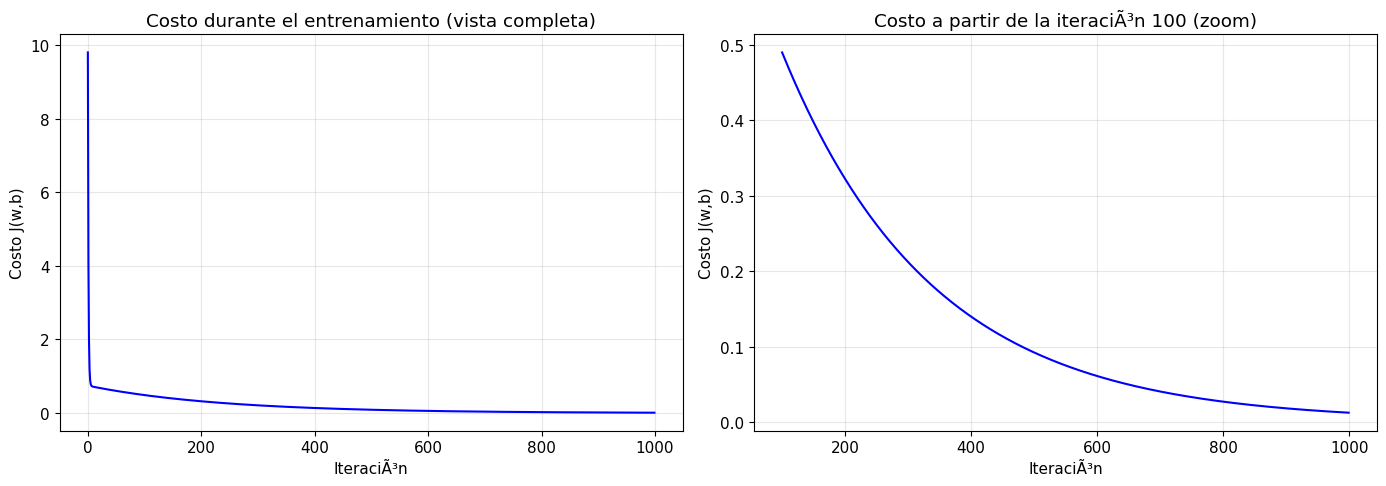

In [67]:
# GrÃƒÂ¡fica del costo a lo largo de las iteraciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toda la curva de costo
axes[0].plot(J_history, c='blue')
axes[0].set_title('Costo durante el entrenamiento (vista completa)')
axes[0].set_xlabel('IteraciÃƒÂ³n')
axes[0].set_ylabel('Costo J(w,b)')
axes[0].grid(True, alpha=0.3)

# Zoom: a partir de la iteraciÃƒÂ³n 100
axes[1].plot(range(100, len(J_history)), J_history[100:], c='blue')
axes[1].set_title('Costo a partir de la iteraciÃƒÂ³n 100 (zoom)')
axes[1].set_xlabel('IteraciÃƒÂ³n')
axes[1].set_ylabel('Costo J(w,b)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

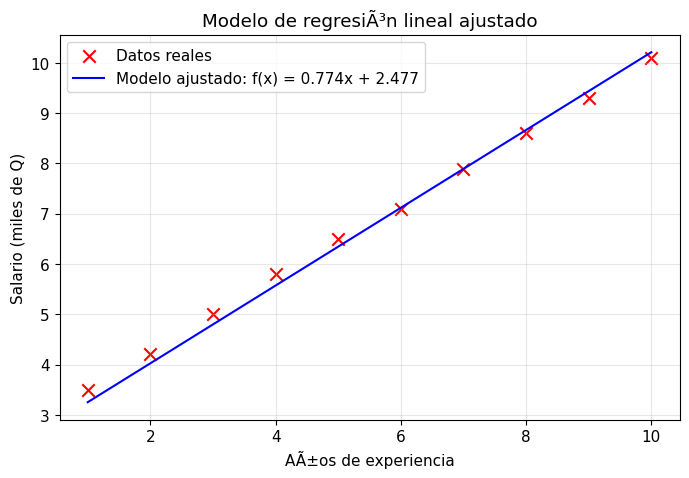

In [68]:
# Calcular las predicciones finales con el modelo entrenado
predicciones_finales = compute_model_output(x_train, w_final, b_final)

# Visualizar el ajuste sobre los datos reales
plt.scatter(x_train, y_train, marker='x', c='red', s=80, label='Datos reales')
plt.plot(x_train, predicciones_finales, c='blue',
         label=f'Modelo ajustado: f(x) = {w_final:.3f}x + {b_final:.3f}')
plt.title('Modelo de regresiÃƒÂ³n lineal ajustado')
plt.xlabel('AÃƒÂ±os de experiencia')
plt.ylabel('Salario (miles de Q)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Hacer predicciones con el modelo

Ya tenemos un modelo entrenado. UsÃƒÂ©moslo para predecir el salario para nuevos casos.

### Ã¢Å“ÂÃ¯Â¸Â Ejercicio 5: Predicciones para casos nuevos

Usa el modelo entrenado (con `w_final` y `b_final`) para estimar el salario de tres profesionales con diferentes aÃƒÂ±os de experiencia.

In [69]:
# Casos nuevos a predecir
casos = [2.5, 6.5, 12.0]  # aÃƒÂ±os de experiencia

print('Predicciones del modelo entrenado:')
print('-' * 55)

for x_nuevo in casos:
    ### TU CÃƒâ€œDIGO AQUÃƒÂ ### (1 lÃƒÂ­nea)
    # Calcula la predicciÃƒÂ³n usando w_final, b_final y x_nuevo
    # Pista: salario_predicho = w_final * x_nuevo + b_final
    salario_predicho = None  # Ã¢â€ Â reemplaza None con tu cÃƒÂ¡lculo

    salario_predicho = w_final * x_nuevo + b_final

    ### FIN DEL CÃƒâ€œDIGO ###

    if salario_predicho is not None:
        print(f'  {x_nuevo:5.1f} aÃƒÂ±os de experiencia  Ã¢â€ â€™  Q {salario_predicho * 1000:8.2f} mensuales')
    else:
        print(f'  {x_nuevo:5.1f} aÃƒÂ±os Ã¢â€ â€™ Ã¢Å¡ Ã¯Â¸Â aÃƒÂºn no implementado')

Predicciones del modelo entrenado:
-------------------------------------------------------
    2.5 aÃƒÂ±os de experiencia  Ã¢â€ â€™  Q  4411.32 mensuales
    6.5 aÃƒÂ±os de experiencia  Ã¢â€ â€™  Q  7505.86 mensuales
   12.0 aÃƒÂ±os de experiencia  Ã¢â€ â€™  Q 11760.86 mensuales


## 10. VisualizaciÃƒÂ³n de la superficie de costo

Para terminar, veamos en un mapa cÃƒÂ³mo $J(w, b)$ se ve sobre el espacio de parÃƒÂ¡metros y quÃƒÂ© trayectoria siguiÃƒÂ³ el descenso de gradiente para llegar al mÃƒÂ­nimo. **Esta celda ya estÃƒÂ¡ completamente escrita** Ã¢â‚¬â€ solo ejecÃƒÂºtala y observa.

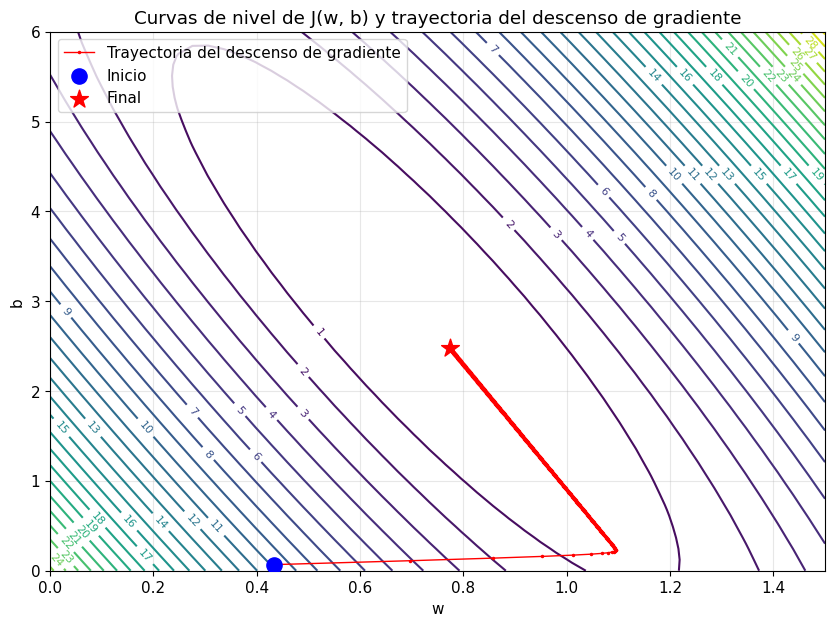

In [70]:
# Generamos una malla de valores de w y b para visualizar el costo
w_range = np.linspace(0, 1.5, 50)
b_range = np.linspace(0, 6, 50)
W, B = np.meshgrid(w_range, b_range)

# Calculamos el costo en cada punto de la malla (sÃƒÂ­, con dos for explÃƒÂ­citos)
Z = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])

# Extraer la trayectoria del descenso de gradiente
ws = [p[0] for p in params_history]
bs = [p[1] for p in params_history]

# GrÃƒÂ¡fico de curvas de nivel (contornos)
fig, ax = plt.subplots(figsize=(10, 7))
contour = ax.contour(W, B, Z, levels=30, cmap='viridis')
ax.clabel(contour, inline=True, fontsize=8)
ax.plot(ws, bs, 'r.-', markersize=3, linewidth=1, label='Trayectoria del descenso de gradiente')
ax.scatter([ws[0]], [bs[0]], c='blue', s=120, marker='o', label='Inicio', zorder=5)
ax.scatter([w_final], [b_final], c='red', s=180, marker='*', label='Final', zorder=5)
ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_title('Curvas de nivel de J(w, b) y trayectoria del descenso de gradiente')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 11. Retos adicionales Ã°Å¸Å½Â¯

Si ya completaste los ejercicios anteriores, intenta los siguientes retos para profundizar.

### Reto 1: Efecto de la tasa de aprendizaje

Ejecuta el descenso de gradiente con diferentes valores de $\alpha$ y observa quÃƒÂ© ocurre:
- $\alpha = 0.001$ (muy pequeÃƒÂ±o Ã¢â‚¬â€ convergencia lenta)
- $\alpha = 0.01$ (el que usamos Ã¢â‚¬â€ convergencia razonable)
- $\alpha = 0.1$ (mÃƒÂ¡s rÃƒÂ¡pidoÃ¢â‚¬Â¦ Ã‚Â¿siempre estable?)
- $\alpha = 0.3$ (Ã‚Â¿quÃƒÂ© pasa aquÃƒÂ­?)


--- ÃŽÂ± = 0.001 ---
IteraciÃƒÂ³n     0: Costo =  23.4111  |  w =  0.0434, b =  0.0068
IteraciÃƒÂ³n    10: Costo =  10.9114  |  w =  0.3937, b =  0.0628
IteraciÃƒÂ³n    20: Costo =   5.3025  |  w =  0.6280, b =  0.1021
IteraciÃƒÂ³n    30: Costo =   2.7847  |  w =  0.7847, b =  0.1302
IteraciÃƒÂ³n    40: Costo =   1.6535  |  w =  0.8894, b =  0.1509
IteraciÃƒÂ³n    50: Costo =   1.1444  |  w =  0.9593, b =  0.1665
IteraciÃƒÂ³n    60: Costo =   0.9144  |  w =  1.0058, b =  0.1788
IteraciÃƒÂ³n    70: Costo =   0.8095  |  w =  1.0367, b =  0.1888
IteraciÃƒÂ³n    80: Costo =   0.7608  |  w =  1.0572, b =  0.1973
IteraciÃƒÂ³n    90: Costo =   0.7372  |  w =  1.0706, b =  0.2048
IteraciÃƒÂ³n    99: Costo =   0.7260  |  w =  1.0786, b =  0.2110

--- ÃŽÂ± = 0.01 ---
IteraciÃƒÂ³n     0: Costo =   9.7955  |  w =  0.4340, b =  0.0680
IteraciÃƒÂ³n    10: Costo =   0.7152  |  w =  1.0934, b =  0.2187
IteraciÃƒÂ³n    20: Costo =   0.6854  |  w =  1.0902, b =  0.2730
IteraciÃƒÂ³n    30: Costo =   0.6

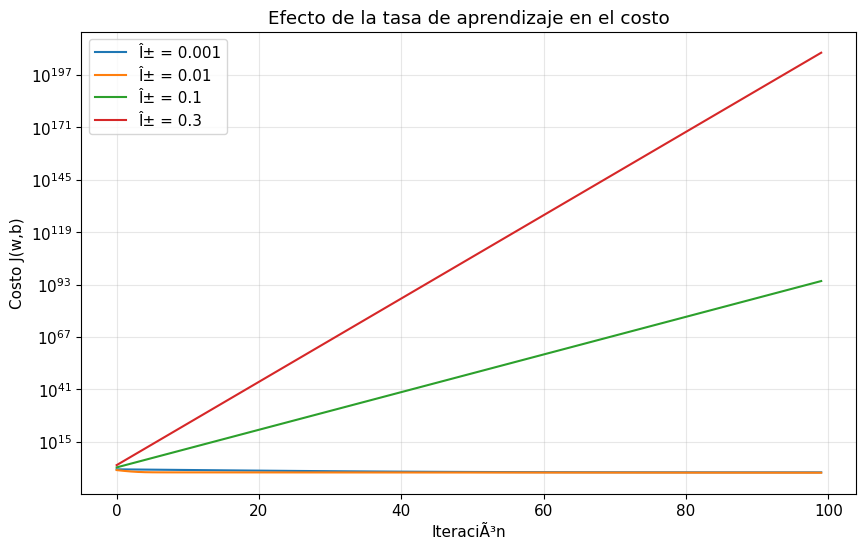


Ã°Å¸â€™Â­ Ã‚Â¿QuÃƒÂ© observas? Ã‚Â¿CuÃƒÂ¡l tasa converge mÃƒÂ¡s rÃƒÂ¡pido? Ã‚Â¿Alguna diverge?


In [71]:
# Reto 1: experimenta con diferentes tasas de aprendizaje
tasas = [0.001, 0.01, 0.1, 0.3]

fig, ax = plt.subplots(figsize=(10, 6))

for alpha in tasas:
    print(f'\n--- ÃŽÂ± = {alpha} ---')
    try:
        _, _, J_hist, _ = gradient_descent(x_train, y_train, 0.0, 0.0, alpha, 100)
        ax.plot(J_hist, label=f'ÃŽÂ± = {alpha}')
    except Exception as e:
        print(f'  Ã¢Å¡ Ã¯Â¸Â Error: {e}')

ax.set_xlabel('IteraciÃƒÂ³n')
ax.set_ylabel('Costo J(w,b)')
ax.set_title('Efecto de la tasa de aprendizaje en el costo')
ax.set_yscale('log')  # escala logarÃƒÂ­tmica para apreciar mejor las diferencias
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print('\nÃ°Å¸â€™Â­ Ã‚Â¿QuÃƒÂ© observas? Ã‚Â¿CuÃƒÂ¡l tasa converge mÃƒÂ¡s rÃƒÂ¡pido? Ã‚Â¿Alguna diverge?')

### Reto 2: Implementa una funciÃƒÂ³n de evaluaciÃƒÂ³n

Implementa una funciÃƒÂ³n que calcule dos mÃƒÂ©tricas para evaluar tu modelo:

- **MAE** (Error Absoluto Medio): $\;\;\dfrac{1}{m} \sum_{i=0}^{m-1} \left| f_{w,b}(x^{(i)}) - y^{(i)} \right|$

- **RMSE** (RaÃƒÂ­z del Error CuadrÃƒÂ¡tico Medio): $\;\;\sqrt{\dfrac{1}{m} \sum_{i=0}^{m-1} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2}$

In [72]:
def evaluar_modelo(x, y, w, b):
    """
    Calcula MAE y RMSE para el modelo.

    Returns:
        mae (float):  Error Absoluto Medio
        rmse (float): RaÃƒÂ­z del Error CuadrÃƒÂ¡tico Medio
    """
    m = len(x)
    suma_abs = 0       # acumulador para MAE
    suma_cuadrada = 0  # acumulador para RMSE

    ### TU CÃƒâ€œDIGO AQUÃƒÂ ###
    # Pista 1: usa abs(...) para el valor absoluto
    # Pista 2: itera sobre los m ejemplos con un ciclo for
    # Pista 3: en cada iteraciÃƒÂ³n, calcula la predicciÃƒÂ³n y el error,
    #          luego acumula |error| en suma_abs y error**2 en suma_cuadrada

    for i in range(m):
        
        fwb_i = w * x[i] + b
        error_i = fwb_i - y[i]

        # MAE
        suma_abs += abs(error_i)

        # RMSE
        suma_cuadrada += error_i ** 2


    ### FIN DEL CÃƒâ€œDIGO ###

    mae = suma_abs / m
    rmse = math.sqrt(suma_cuadrada / m)
    return mae, rmse


# Ã°Å¸Â§Âª Probar la funciÃƒÂ³n
mae, rmse = evaluar_modelo(x_train, y_train, w_final, b_final)
print(f'MAE  = {mae:.4f} miles de Q  (Ã¢â€°Ë† Q {mae*1000:.2f} de error promedio)')
print(f'RMSE = {rmse:.4f} miles de Q  (Ã¢â€°Ë† Q {rmse*1000:.2f})')

MAE  = 0.1356 miles de Q  (Ã¢â€°Ë† Q 135.55 de error promedio)
RMSE = 0.1571 miles de Q  (Ã¢â€°Ë† Q 157.13)


### Reto 3: Probar con tus propios datos

Modifica `x_train` y `y_train` con datos inventados por ti (por ejemplo: horas de estudio vs. nota del examen, o cualquier otro caso) y vuelve a entrenar el modelo. Ã‚Â¿QuÃƒÂ© tan bien ajusta?

Ã°Å¸â€™Â¡ *Tip:* si los valores de tu nuevo dataset son muy distintos en escala, puede que necesites ajustar la tasa de aprendizaje.

Iniciando entrenamiento...
IteraciÃƒÂ³n     0: Costo =  62.6028  |  w =  1.0975, b =  0.1641
IteraciÃƒÂ³n   100: Costo =   4.5135  |  w =  2.7129, b =  0.9777
IteraciÃƒÂ³n   200: Costo =   4.2953  |  w =  2.6466, b =  1.4394
IteraciÃƒÂ³n   300: Costo =   4.1520  |  w =  2.5928, b =  1.8136
IteraciÃƒÂ³n   400: Costo =   4.0579  |  w =  2.5493, b =  2.1169
IteraciÃƒÂ³n   500: Costo =   3.9961  |  w =  2.5140, b =  2.3627
IteraciÃƒÂ³n   600: Costo =   3.9555  |  w =  2.4853, b =  2.5618
IteraciÃƒÂ³n   700: Costo =   3.9288  |  w =  2.4622, b =  2.7233
IteraciÃƒÂ³n   800: Costo =   3.9113  |  w =  2.4434, b =  2.8541
IteraciÃƒÂ³n   900: Costo =   3.8998  |  w =  2.4281, b =  2.9601
IteraciÃƒÂ³n   999: Costo =   3.8923  |  w =  2.4159, b =  3.0453

Ã°Å¸Å½Â¯ Entrenamiento finalizado:
   w final     = 2.4159
   b final     = 3.0453
   costo final = 3.892330


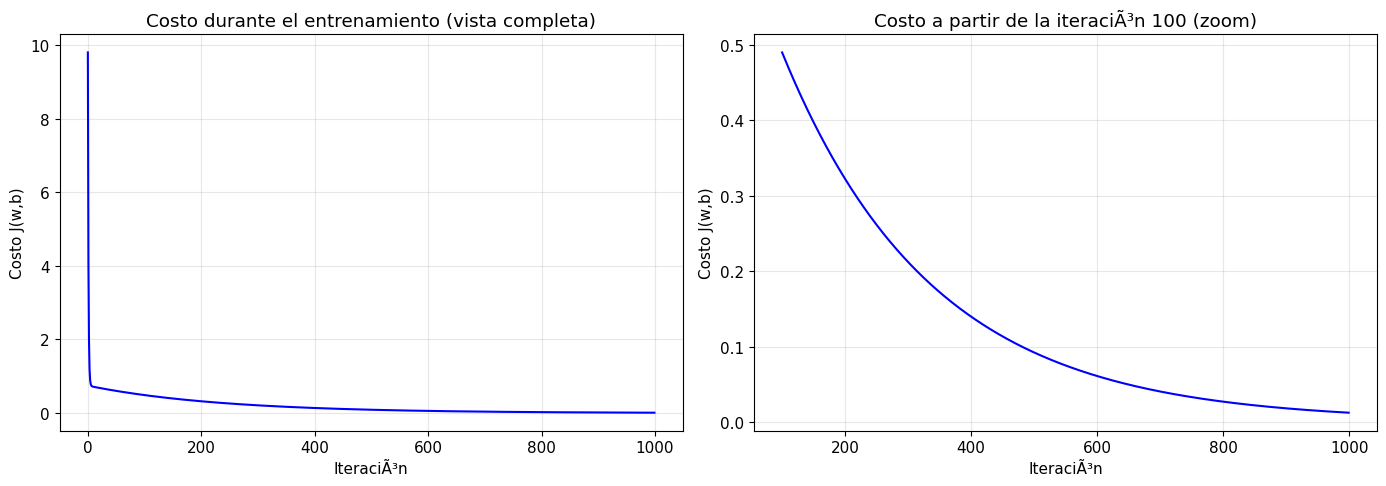

In [86]:
# HiperparÃƒÂ¡metros del entrenamiento
w_inicial2 = 0.0
b_inicial2 = 0.0
tasa_aprendizaje2 = 0.01
iteraciones2 = 1000

x_train2 = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y_train2 = np.array([3.5, 6.0, 8.0, 15.0, 20.0, 21.0, 22.0, 22.5, 23.0, 23.1])

print('Iniciando entrenamiento...')
print('=' * 70)

w_final2, b_final2, J_history2, params_history2 = gradient_descent(
    x_train2, y_train2,
    w_inicial2, b_inicial2,
    tasa_aprendizaje2, iteraciones2
)

print('=' * 70)
print(f'\nÃ°Å¸Å½Â¯ Entrenamiento finalizado:')
print(f'   w final     = {w_final2:.4f}')
print(f'   b final     = {b_final2:.4f}')
print(f'   costo final = {J_history2[-1]:.6f}')

# GrÃƒÂ¡fica del costo a lo largo de las iteraciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Toda la curva de costo
axes[0].plot(J_history, c='blue')
axes[0].set_title('Costo durante el entrenamiento (vista completa)')
axes[0].set_xlabel('IteraciÃƒÂ³n')
axes[0].set_ylabel('Costo J(w,b)')
axes[0].grid(True, alpha=0.3)

# Zoom: a partir de la iteraciÃƒÂ³n 100
axes[1].plot(range(100, len(J_history2)), J_history[100:], c='blue')
axes[1].set_title('Costo a partir de la iteraciÃƒÂ³n 100 (zoom)')
axes[1].set_xlabel('IteraciÃƒÂ³n')
axes[1].set_ylabel('Costo J(w,b)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Al final no converge, puse datos un poco mas reales(en mi opinion) y ahora el error del modelo es muy grande. Probe con varias alpha pero con el que tuve mejores resultados fue el de 0.01.

## 12. Conclusiones

Ã‚Â¡Felicidades! Ã°Å¸Å½â€° Has implementado desde cero un algoritmo completo de regresiÃƒÂ³n lineal:

Ã¢Å“â€¦ FunciÃƒÂ³n del modelo $f_{w,b}(x) = wx + b$  
Ã¢Å“â€¦ FunciÃƒÂ³n de costo $J(w,b)$  
Ã¢Å“â€¦ CÃƒÂ¡lculo del gradiente $\frac{\partial J}{\partial w}$ y $\frac{\partial J}{\partial b}$  
Ã¢Å“â€¦ Algoritmo de descenso de gradiente  
Ã¢Å“â€¦ Entrenamiento, predicciÃƒÂ³n y evaluaciÃƒÂ³n del modelo  

### Preguntas para reflexionar

1. Ã‚Â¿QuÃƒÂ© pasa si la tasa de aprendizaje es **demasiado grande**? Ã‚Â¿Y si es **demasiado pequeÃƒÂ±a**?

**Cuando la tasa es demasiado grande la tiende a que no converga el entreganmiento. Cuando es muy pequeÃ±a puede llegar a converger, pero tardÃ¡ndose mÃ¡s tiempo del necesario, entonces, entonces no es eficiente el proceso de entrenamiento.**


2. Ã‚Â¿CÃƒÂ³mo afectan los valores iniciales de $w$ y $b$ al resultado final?

**Si los valores son mÃ¡s cercanos a los valores Ã³ptimos, el proceso de entrenamiento serÃ¡ mÃ¡s corto.**

3. Ã‚Â¿Por quÃƒÂ© dividimos entre $2m$ en la funciÃƒÂ³n de costo y no solo entre $m$?

**Esto es una ayuda puramente matemÃ¡tica para que, de ser necesario, hacer una derivada, la derivada resultante del exponencial del error, se cancele con esa divisiÃ³n de 2.**

4. Ã‚Â¿QuÃƒÂ© tan bien crees que generaliza este modelo a aÃƒÂ±os de experiencia muy fuera del rango entrenado (por ejemplo, 30 aÃƒÂ±os)?

**No, creo que el comportamiento real es distinto. Los aÃ±os de experiencia no representan unos ingresos lineales, por lo que no es algo que se pueda ver en la vida real.**

### PrÃƒÂ³ximos pasos

En las siguientes clases veremos:
- **VectorizaciÃƒÂ³n con NumPy**: el mismo algoritmo, mucho mÃƒÂ¡s rÃƒÂ¡pido y conciso (sin ciclos `for`).
- **RegresiÃƒÂ³n lineal multivariable**: cuando tenemos mÃƒÂ¡s de una caracterÃƒÂ­stica de entrada.
- **NormalizaciÃƒÂ³n de caracterÃƒÂ­sticas**: clave cuando las variables tienen escalas muy distintas.